# Cene stanovanj v Sloveniji

V tej analizi bom primerjala oglaševane cene stanovanj, ki so naprodaj na portalu
[Moji kvadrati](https://mojikvadrati.com) in ugotovila:

1. kako se cena na kvadratni meter razlikuje med regijami in kraji,
2. katere četrti v Ljubljani so najdražje,
3. kako na ceno vplivajo velikost, starost stavbe in število sob,
4. ali lahko s preprostim modelom napovemo ceno stanovanja in poiščemo
   oglase, ki so glede na svoje lastnosti nenavadno poceni.

Podatke zajamemo s programom `scrape.py`, iz shranjenih strani pa jih
izlušči program `čiščenje.py`. Upoštevati moramo, da gre za **oglaševane**
cene, ki so praviloma nekoliko višje od cen, po katerih se stanovanja
dejansko prodajo.

In [50]:
import matplotlib.pyplot as plt     # knjižnica z grafi
import pandas as pd     # knjižnica za urejanje csv

import drek

pd.set_option("display.float_format", "{:,.0f}".format)     # vse decimalke na tri mesta

## Podatki

Vsaka vrstica predstavlja en oglas. Oglase s cenami na kvadratni meter pod
500 € ali nad 15.000 € ter stanovanja, manjša od 15 m² ali večja od 400 m²,
sem izločila, saj gre skoraj vedno za napake pri vnosu ali za posebne primere
(npr. prodaja sobe v stanovanju oz. deleža stanovanja). Portal objavlja tudi oglase iz tujine,
ki jih je program `čiščenje.py` izločil že pri čiščenju podatkov.

In [51]:
stanovanja = drek.nalozi_podatke("stanovanja.csv")
stanovanja.head(10)

,id,regija,kraj,predel,sobnost,st_sob,velikost,leto_izgradnje,cena,cena_na_m2,povezava,novogradnja
0,544067,Podravska,Maribor,Spodnje Radvanje,1-sobno,1,39,"1,968",123000,3162,https://mojikvadrati.com/nepremicnina/544067-p...,False
1,543865,Obalno - kraška,Izola,Jagodje,1-sobno,1,34,"1,996",285000,8507,https://mojikvadrati.com/nepremicnina/543865-p...,False
2,543853,Gorenjska,Kranj,Planina I,2-sobno,2,60,"1,979",240000,4034,https://mojikvadrati.com/nepremicnina/543853-p...,False
3,543776,Ljubljana,Ljubljana,Šiška,2-sobno,2,36,"1,969",260000,7123,https://mojikvadrati.com/nepremicnina/543776-p...,False
4,543672,Ljubljana,Ljubljana,Šiška,2-sobno,2,44,"1,969",258800,5842,https://mojikvadrati.com/nepremicnina/543672-p...,False
5,543476,Gorenjska,Jesenice,Jesenice,3-sobno,3,68,"2,010",250000,3693,https://mojikvadrati.com/nepremicnina/543476-p...,False
6,543366,Ljubljana okolica,Domžale,Domžale,Garsonjera,0,33,"1,991",192000,5818,https://mojikvadrati.com/nepremicnina/543366-p...,False
7,542275,Savinjska,Celje,Center,2-sobno,2,65,"1,976",209000,3215,https://mojikvadrati.com/nepremicnina/542275-p...,False
8,540211,Ljubljana,Ljubljana,Center,4-sobno,4,135,"1,876",1417500,10530,https://mojikvadrati.com/nepremicnina/540211-p...,False
9,538550,Ljubljana,Ljubljana,Bežigrad,"3,5-sobno",4,75,"1,986",410000,5496,https://mojikvadrati.com/nepremicnina/538550-p...,False


In [52]:
stanovanja[["cena", "velikost", "cena_na_m2", "leto_izgradnje"]].describe()

,cena,velikost,cena_na_m2,leto_izgradnje
count,"1,186","1,186","1,186","1,058"
mean,"430,551",100,"4,514","1,964"
std,"319,740",56,"2,074",75
min,"45,000",18,573,"1,451"
25%,"239,000",63,"2,956","1,936"
50%,"330,000",84,"4,230","1,980"
75%,"509,238",123,"5,568","2,023"
max,"2,971,000",396,"14,854","2,029"


Ker je mediana (50%) precej nižja od povprečja (mean), imamo nekaj zelo dragih stanovanj, ki vlečejo povprečje navzgor, zato bomo pri cenah raje uporabljali mediano, ker je manj občutljiva na izstopajoče vrednosti.



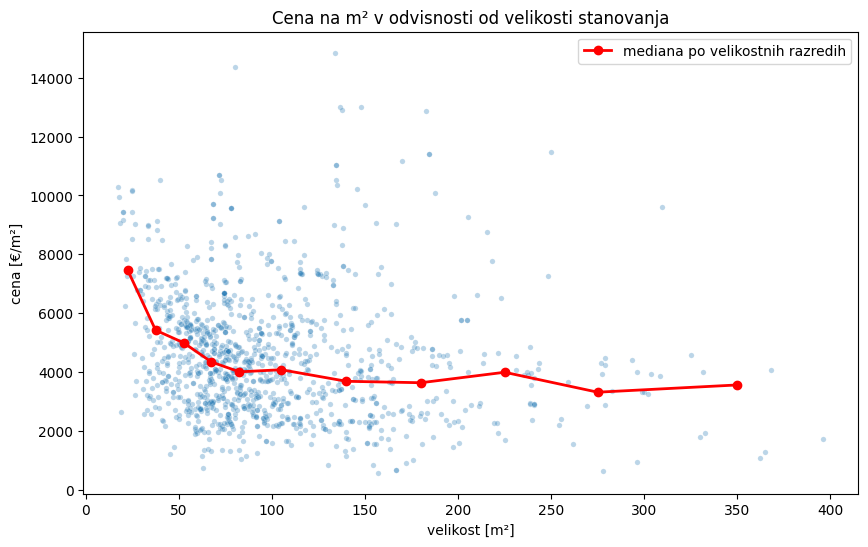

In [53]:
import seaborn as sns     # nariše pike

RAZREDI_VELIKOSTI = [15, 30, 45, 60, 75, 90, 120, 160, 200, 250, 300, 400]

fig, ax = plt.subplots(figsize=(10, 6))     # ustvari sliko in os

# vsako stanovanje je ena pika, alpha nredi prosojnost, s določi velikost pik
sns.scatterplot(
    data=stanovanja,
    x="velikost",
    y="cena_na_m2",
    alpha=0.3,
    s=15,
    ax=ax,
)

# mediana cene na m2 za vsak velikostni razred
razred = pd.cut(stanovanja["velikost"], bins=RAZREDI_VELIKOSTI)     # vsakemu stanovanju pripiše razred velikosti
mediane_razredov = stanovanja.groupby(razred, observed=True)["cena_na_m2"].median()     # izračuna mediano cene na kvadrat za vsak razred
sredine = [interval.mid for interval in mediane_razredov.index]     # sredina razreda, x-koordinata rdeče točke

ax.plot(sredine, mediane_razredov.values, color="red", marker="o",
        linewidth=2, label="mediana po velikostnih razredih")      # ax.plot poveže mediane razredov v rdečo črto, label pa se pokaže v legendi

ax.set_title("Cena na m² v odvisnosti od velikosti stanovanja")
ax.set_xlabel("velikost [m²]")
ax.set_ylabel("cena [€/m²]")
ax.legend()
plt.show()

Ugotovimo, da cena na kvadrat z večanjem stanovanj iz 15 m² na 75 m² pada. Začne pri približno 7500 €/m², potem pa se ustali pri približno 4000 €/m².

## Primerjava regij

In [54]:
po_regijah = drek.mediane(stanovanja, "regija")
po_regijah

,stevilo_oglasov,mediana_cene_na_m2,mediana_cene,mediana_velikosti
regija,,,,
Ljubljana,412,"5,486","509,826",98
Obalno - kraška,220,"5,180","354,000",74
Ljubljana okolica,99,"3,753","319,000",98
Jugovzhodna Slovenija,20,"3,552","242,182",75
Gorenjska,95,"3,406","277,000",82
Goriška,39,"3,052","286,207",82
Savinjska,62,"2,842","204,262",74
Podravska,157,"2,763","235,743",83
Pomurska,52,"2,668","264,631",77


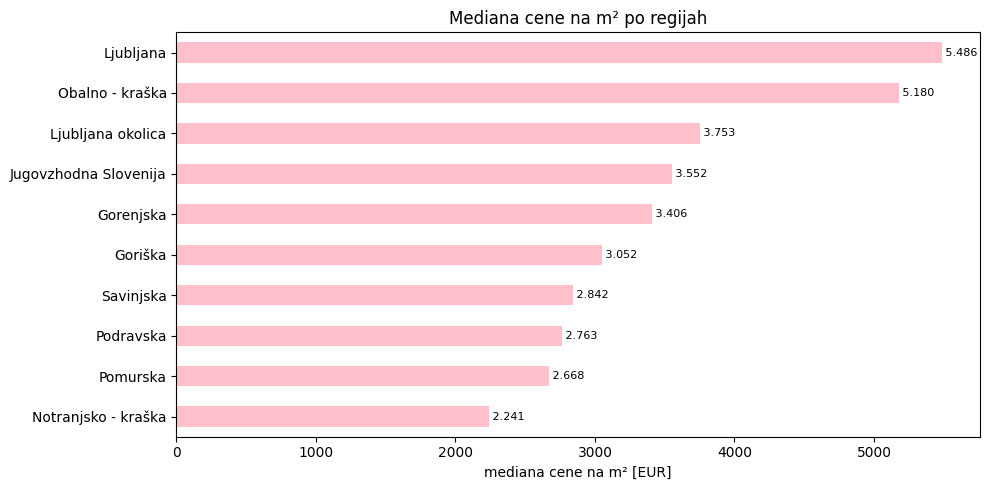

In [55]:
drek.narisi_stolpce(po_regijah, "Mediana cene na m² po regijah")


## Primerjava krajev

Upoštevamo le kraje z vsaj desetimi oglasi, saj je pri manj oglasih
mediana preveč odvisna od posameznih stanovanj.

In [56]:
po_krajih = drek.mediane(stanovanja, "kraj")
po_krajih

,stevilo_oglasov,mediana_cene_na_m2,mediana_cene,mediana_velikosti
kraj,,,,
Piran,116,"5,892","350,000",67
Ljubljana,412,"5,486","509,826",98
Izola,43,"4,938","495,600",93
Koper,52,"4,488","337,000",78
Domžale,23,"4,397","328,000",75
Kamnik,20,"4,182","392,500",102
Ljutomer,27,"3,861","284,689",76
Medvode,14,"3,790","592,453",156
Kranj,42,"3,424","341,154",106


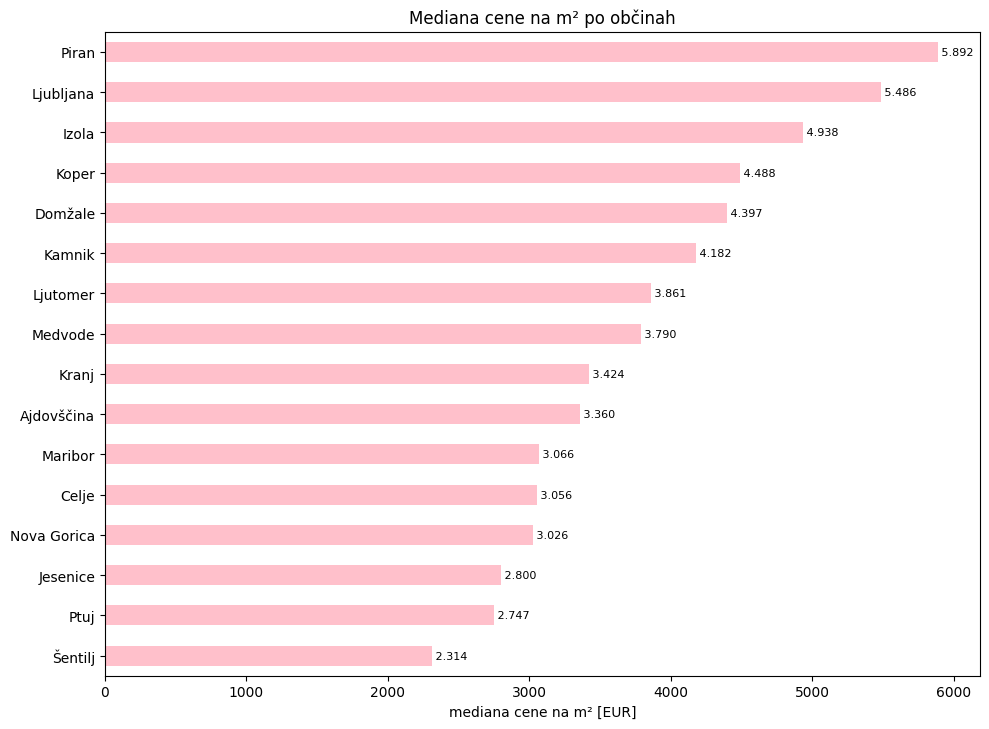

In [57]:
drek.narisi_stolpce(po_krajih, "Mediana cene na m² po občinah")

## Ljubljanske četrti

In [58]:
ljubljana = stanovanja[stanovanja["kraj"] == "Ljubljana"]     # obdela samo tiste, za katere je trditev True
po_cetrtih = drek.mediane(ljubljana, "predel")
po_cetrtih

,stevilo_oglasov,mediana_cene_na_m2,mediana_cene,mediana_velikosti
predel,,,,
Center,104,"6,488","649,000",104
Vič-Rudnik,68,"5,728","499,000",88
Bežigrad,91,"5,483","479,000",96
Šiška,103,"4,823","549,000",116
Moste-Polje,46,"4,745","347,500",71


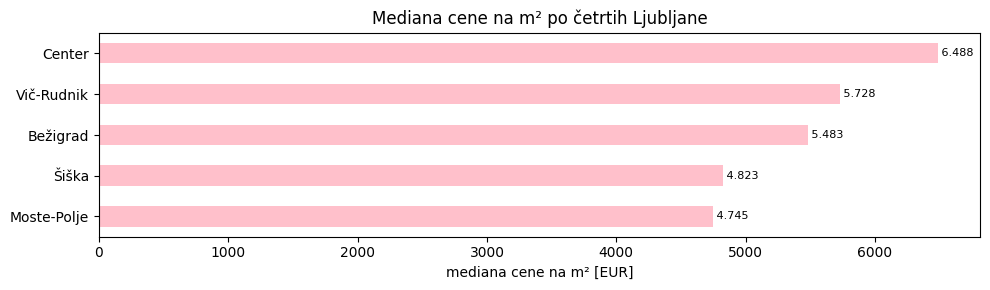

In [59]:
drek.narisi_stolpce(po_cetrtih, "Mediana cene na m² po četrtih Ljubljane")

## Kaj vpliva na ceno?

### Velikost stanovanja


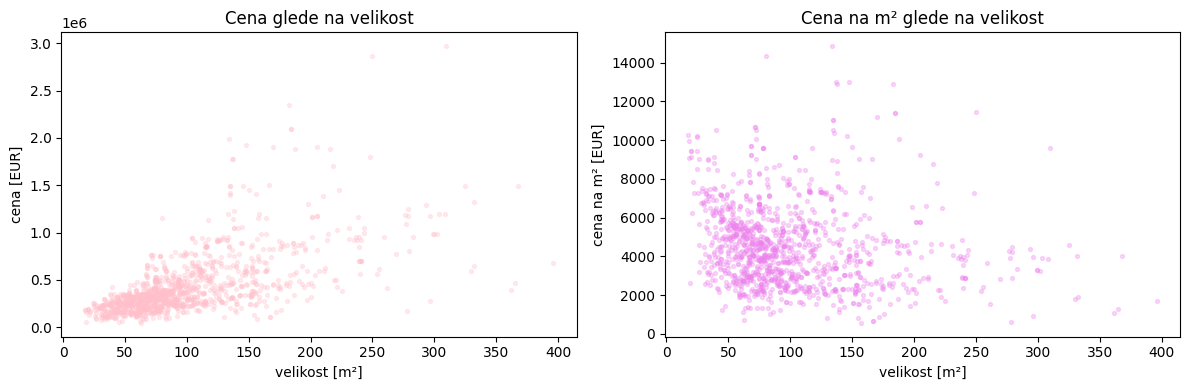

In [60]:
fig, (levo, desno) = plt.subplots(1, 2, figsize=(12, 4))     # subplots naredi dva vzporedna grafa
stanovanja.plot.scatter(x="velikost", y="cena", alpha=0.3, s=8, ax=levo, color="pink")
levo.set_xlabel("velikost [m²]")
levo.set_ylabel("cena [EUR]")
levo.set_title("Cena glede na velikost")
stanovanja.plot.scatter(x="velikost", y="cena_na_m2", alpha=0.3, s=8, ax=desno, color="violet")
desno.set_xlabel("velikost [m²]")
desno.set_ylabel("cena na m² [EUR]")
desno.set_title("Cena na m² glede na velikost")
plt.tight_layout()
plt.show()


Po pričakovanjih so večja stanovanja dražja, cena na kvadratni meter pa je
pri manjših stanovanjih višja.

### Obdobje gradnje

Ker bi bilo deljenje stavb na leto nesmiselno, jih razdelimo v obdobja (tako kot pri dajanju velikosti v razrede).

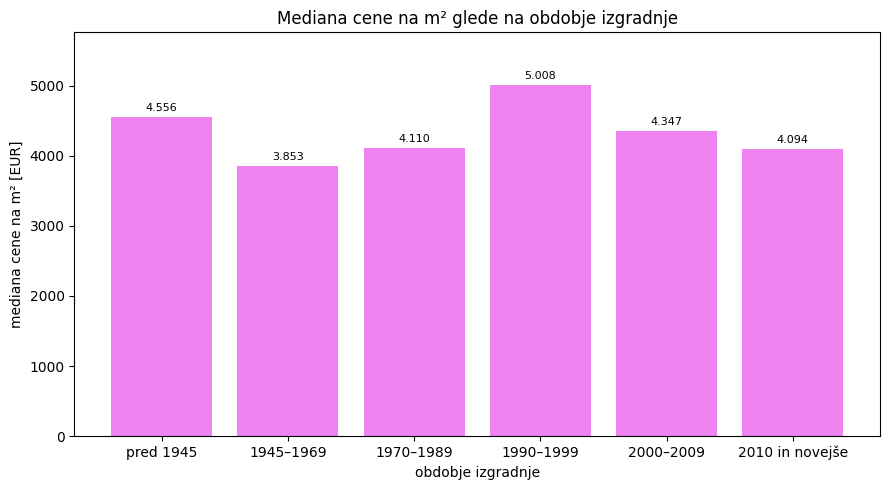

In [63]:
import matplotlib.pyplot as plt
import pandas as pd

from drek import mediane

OBDOBJA_IZGRADNJE = [0, 1945, 1970, 1990, 2000, 2010, 2100]
IMENA_OBDOBIJ = ["pred 1945", "1945–1969", "1970–1989",
                 "1990–1999", "2000–2009", "2010 in novejše"]

# vsakemu stanovanju pripiše obdobje izgradnje
stanovanja["obdobje"] = pd.cut(
    stanovanja["leto_izgradnje"],
    bins=OBDOBJA_IZGRADNJE,
    labels=IMENA_OBDOBIJ,
    right=False,
)

po_obdobjih = mediane(stanovanja, "obdobje", najmanj_oglasov=10)
po_obdobjih = po_obdobjih.sort_index()      # kronološki vrstni red

fig, ax = plt.subplots(figsize=(9, 5))
stolpci = ax.bar(po_obdobjih.index.astype(str),
                 po_obdobjih["mediana_cene_na_m2"], color="violet")

# nad vsak stolpec mediana, pod njo število oglasov
oznake = [
    f"{mediana:,.0f}".replace(",", ".")
    for mediana, stevilo in zip(po_obdobjih["mediana_cene_na_m2"],
                                po_obdobjih["stevilo_oglasov"])
]
ax.bar_label(stolpci, labels=oznake, padding=3, fontsize=8)

ax.set_title("Mediana cene na m² glede na obdobje izgradnje")
ax.set_xlabel("obdobje izgradnje")
ax.set_ylabel("mediana cene na m² [EUR]")
ax.margins(y=0.15)          # prostor za oznake nad stolpci
fig.tight_layout()

### Število sob


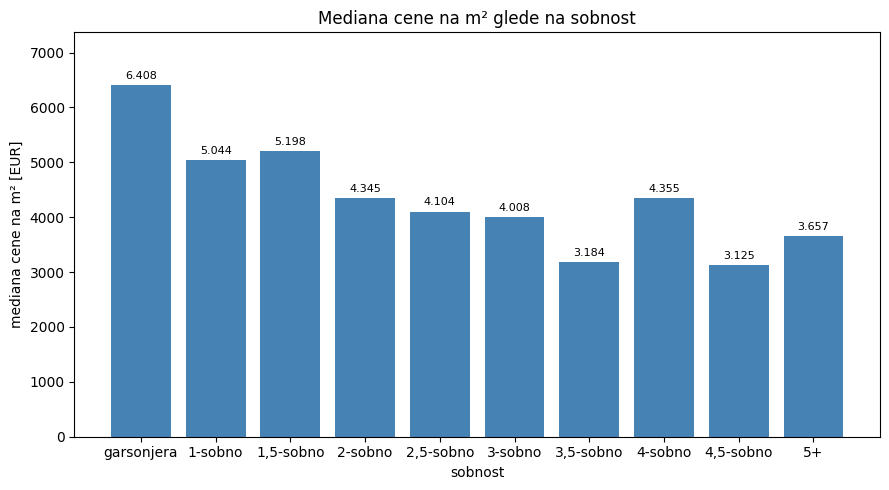

In [65]:
IMENA_SOBNOSTI = {0.5: "garsonjera", 5.0: "5+"}

po_sobnosti = mediane(stanovanja, "st_sob", najmanj_oglasov=10)
po_sobnosti = po_sobnosti.sort_index()      # od garsonjere do 5+


def ime_sobnosti(st_sob):
    """Vrne berljivo ime sobnosti, npr. 2.5 -> '2,5-sobno'."""
    if st_sob in IMENA_SOBNOSTI:
        return IMENA_SOBNOSTI[st_sob]
    stevilo = f"{st_sob:g}".replace(".", ",")
    return f"{stevilo}-sobno"


fig, ax = plt.subplots(figsize=(9, 5))
stolpci = ax.bar([ime_sobnosti(s) for s in po_sobnosti.index],
                 po_sobnosti["mediana_cene_na_m2"], color="steelblue")

oznake = [
    f"{mediana:,.0f}".replace(",", ".")
    for mediana, stevilo in zip(po_sobnosti["mediana_cene_na_m2"],
                                po_sobnosti["stevilo_oglasov"])
]
ax.bar_label(stolpci, labels=oznake, padding=3, fontsize=8)

ax.set_title("Mediana cene na m² glede na sobnost")
ax.set_xlabel("sobnost")
ax.set_ylabel("mediana cene na m² [EUR]")
ax.margins(y=0.15)
fig.tight_layout()

### Novogradnje

Za novogradnje štejemo stanovanja, zgrajena leta 2024 ali pozneje (to
vključuje tudi stanovanja, ki so še v gradnji). Primerjajmo jih s
starejšimi stanovanji v istih regijah. Oglase brez podatka o letu gradnje
pri tej primerjavi izpustimo.

In [66]:
z_letom = stanovanja.dropna(subset=["leto_izgradnje"])
mediane = z_letom.pivot_table(index="regija", columns="novogradnja",
                              values="cena_na_m2", aggfunc="median")
stevila = z_letom.pivot_table(index="regija", columns="novogradnja",
                              values="cena_na_m2", aggfunc="count")
novogradnje = pd.DataFrame({
    "starejša stanovanja": mediane[False],
    "novogradnje": mediane[True],
    "število novogradenj": stevila[True],
})
# Regije z manj kot petimi novogradnjami izpustimo, ker je mediana
# nekaj oglasov preveč naključna.
novogradnje = novogradnje[novogradnje["število novogradenj"] >= 5].copy()
novogradnje["razlika [%]"] = (
    novogradnje["novogradnje"] / novogradnje["starejša stanovanja"] - 1
) * 100
novogradnje.sort_values("razlika [%]", ascending=False)

,starejša stanovanja,novogradnje,število novogradenj,razlika [%]
regija,,,,
Jugovzhodna Slovenija,"2,214","3,808",8,72
Pomurska,"1,522","2,488",26,64
Goriška,"2,953","3,472",20,18
Savinjska,"2,778","2,998",9,8
Ljubljana okolica,"3,790","3,998",12,6
Obalno - kraška,"5,214","5,489",23,5
Ljubljana,"5,362","5,616",107,5
Gorenjska,"3,543","3,686",14,4
Podravska,"2,748","2,821",36,3
